In [1]:
import math
import re
import os

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import MinMaxScaler

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif 
# f_classif simply means

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

In [6]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_curve, roc_auc_score

In [7]:
import pickle

In [8]:
df = pd.read_csv("cardio_train.csv", sep=";")

# Dataset Exploration


In [9]:
list(df.columns)

['id',
 'age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio']

In [10]:
pd.concat([df.head(5), df.sample(5), df.tail(5)])

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
69067,98650,21891,1,160,62.0,180,100,1,1,0,0,1,1
40091,57309,19736,1,160,90.0,120,80,1,1,0,0,1,0
42495,60707,18168,1,168,82.0,127,72,1,1,0,0,0,0
20864,29795,22038,2,165,65.0,110,70,1,1,0,0,1,0
23329,33326,18983,1,152,64.0,110,70,2,1,0,0,1,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [12]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


# Dataset Preprocessing


In [13]:
pd.DataFrame([ df.nunique(), df.dtypes ], index=['Unique Values', 'Data Types'])

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
Unique Values,70000,8076,2,109,287,153,157,3,3,2,2,2,2
Data Types,int64,int64,int64,int64,float64,int64,int64,int64,int64,int64,int64,int64,int64


In [14]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

### Features type


In [15]:
TARGET = 'cardio'
INPUT_FEATURES = ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

In [16]:
pd.DataFrame([df.nunique(), df.dtypes])

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,70000,8076,2,109,287,153,157,3,3,2,2,2,2
1,int64,int64,int64,int64,float64,int64,int64,int64,int64,int64,int64,int64,int64


In [17]:
df.duplicated().sum()

0

In [18]:
pd.DataFrame(
    {
        "Count" : df.isna().sum().sort_values(ascending=False),
        "percent %" : 100.0 * df.isna().sum().sort_values(ascending=False) / len(df),
    }
).T

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
Count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
percent %,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
def drop_unwanted_features(df, features_to_drop):
    print(f"Dropping features: {features_to_drop}")
    
    if features_to_drop in list(df.columns):
        df = df.drop(columns=features_to_drop)
    
    if features_to_drop in INPUT_FEATURES:
        INPUT_FEATURES.remove(features_to_drop)
    return df

In [20]:
df = drop_unwanted_features(df, 'id')

Dropping features: id


In [21]:
list(df.columns)

['age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio']

# EDA & Dataset Visualization


In [22]:
plt.style.use(plt.style.available[12])

Distribution


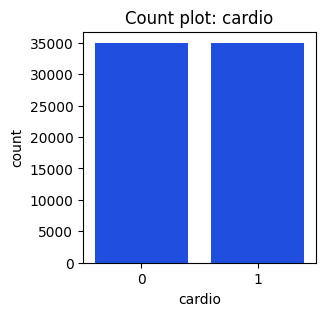

In [23]:
plt.figure(figsize=(3, 3))
plt.title(f"Count plot: {TARGET}")
sns.countplot(df, x=TARGET)
plt.show()

- There is no bias in target column


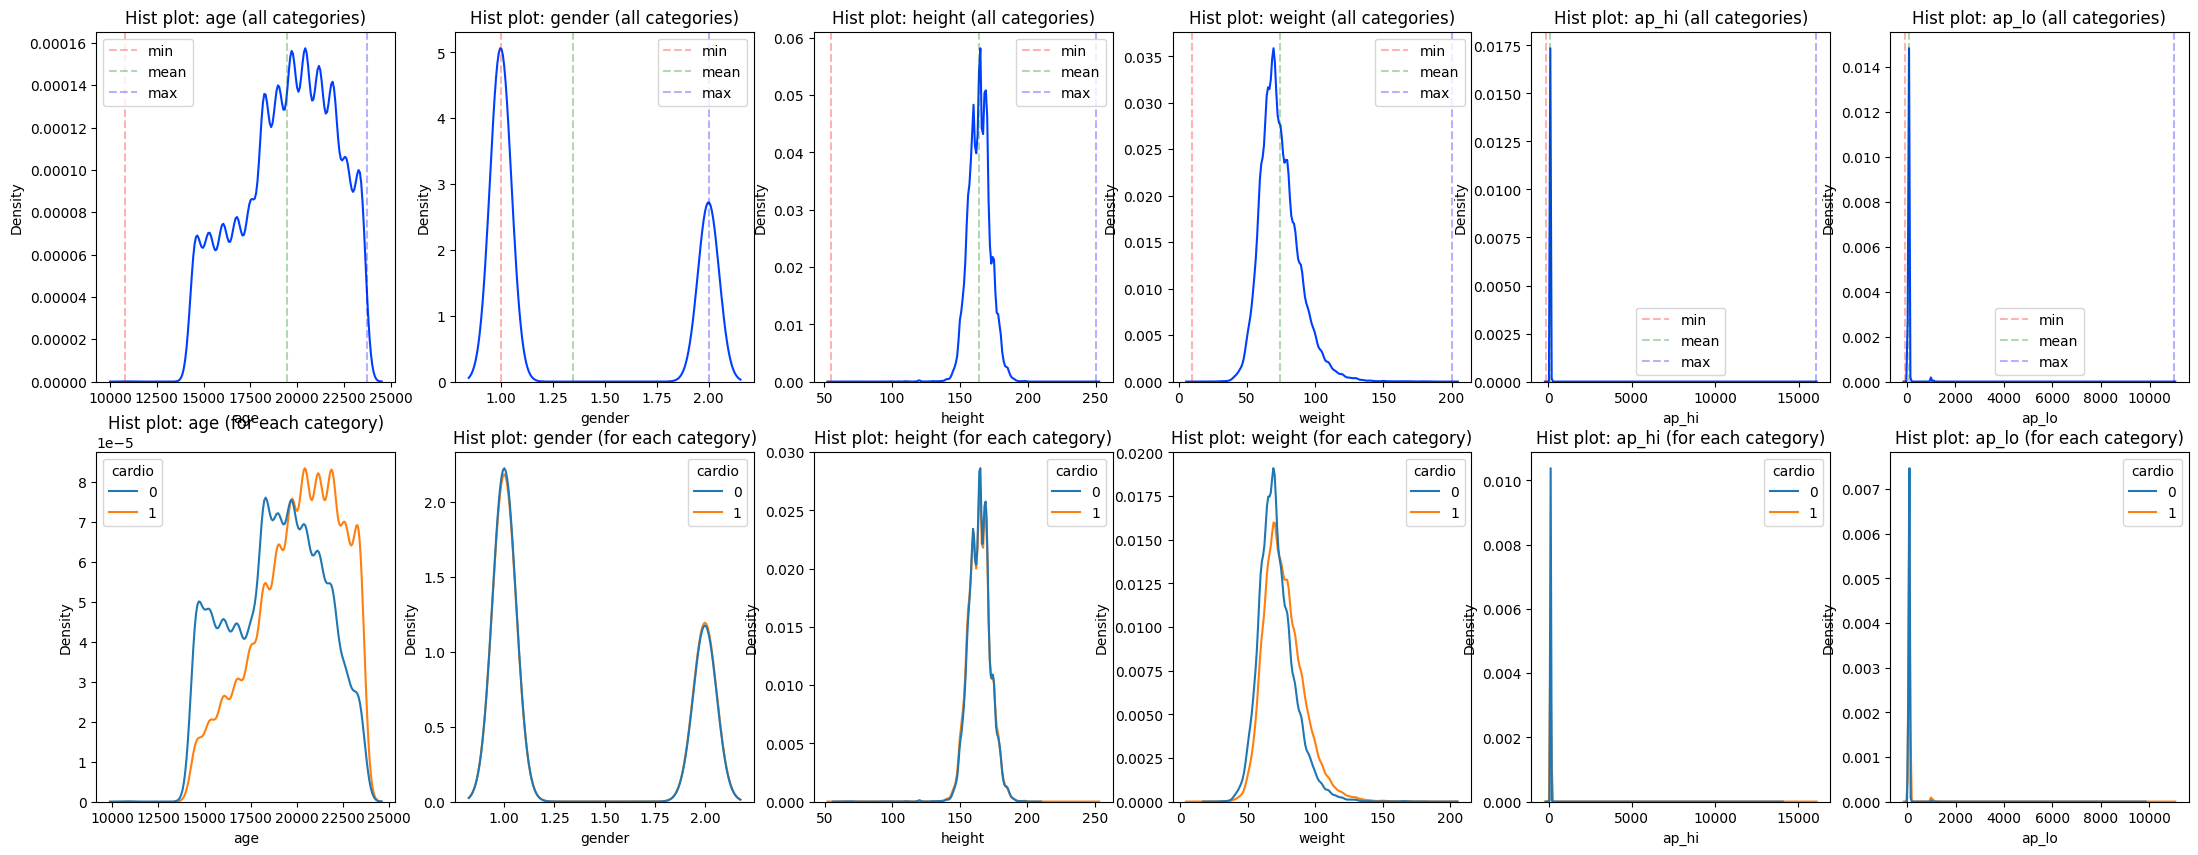

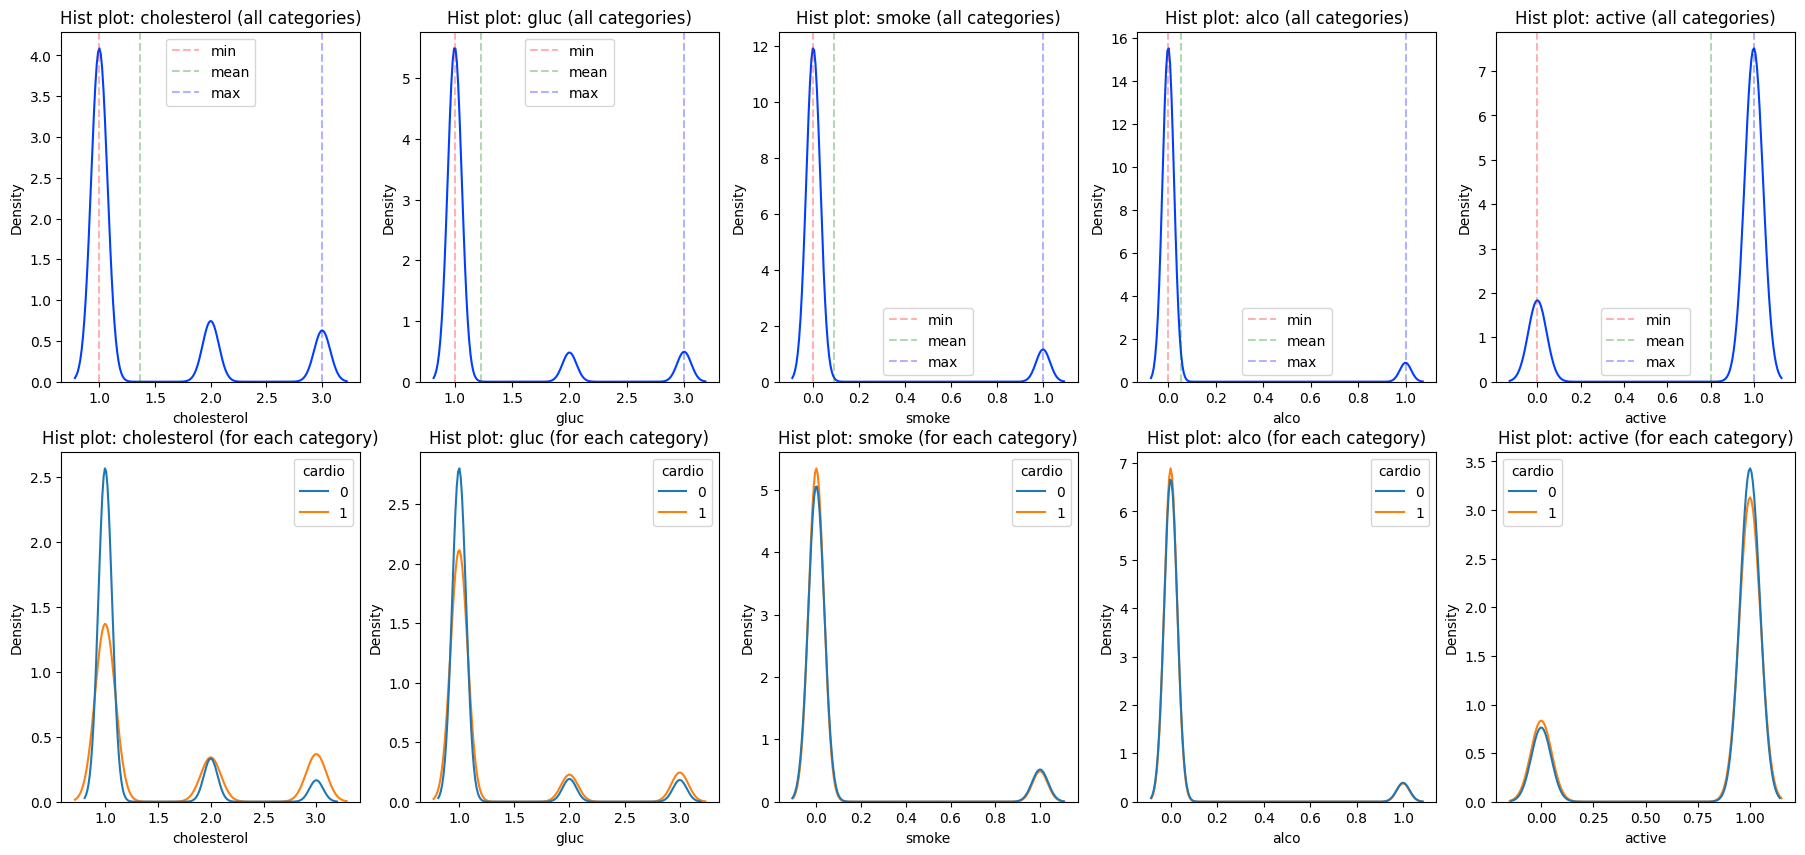

In [24]:
ROW_WIDTH = 6
temp = 0

for num_features in INPUT_FEATURES:
    if temp == 0:
        plt.figure(figsize=(27, 10))
    plt.subplot(2, ROW_WIDTH, temp + 1)
    plt.title(f"Hist plot: {num_features} (all categories)")
    sns.kdeplot(df, x=num_features, )
    
    plt.axvline(x= df[num_features].min(), label="min", color='r', linestyle='--', alpha = 0.3)
    plt.axvline(x= df[num_features].mean(), label="mean", color='g', linestyle='--', alpha = 0.3)
    plt.axvline(x= df[num_features].max(), label="max", color='b', linestyle='--', alpha = 0.3)
    
    plt.legend()
    
    plt.subplot(2, ROW_WIDTH, (temp + 1) + ROW_WIDTH)
    plt.title(f"Hist plot: {num_features} (for each category)")
    
    sns.kdeplot(df, x=num_features, hue=TARGET, palette='tab10')
    
    if temp == ROW_WIDTH - 1:
        plt.show()
    temp = (temp + 1) % ROW_WIDTH

if temp != ROW_WIDTH - 1:
    plt.show()

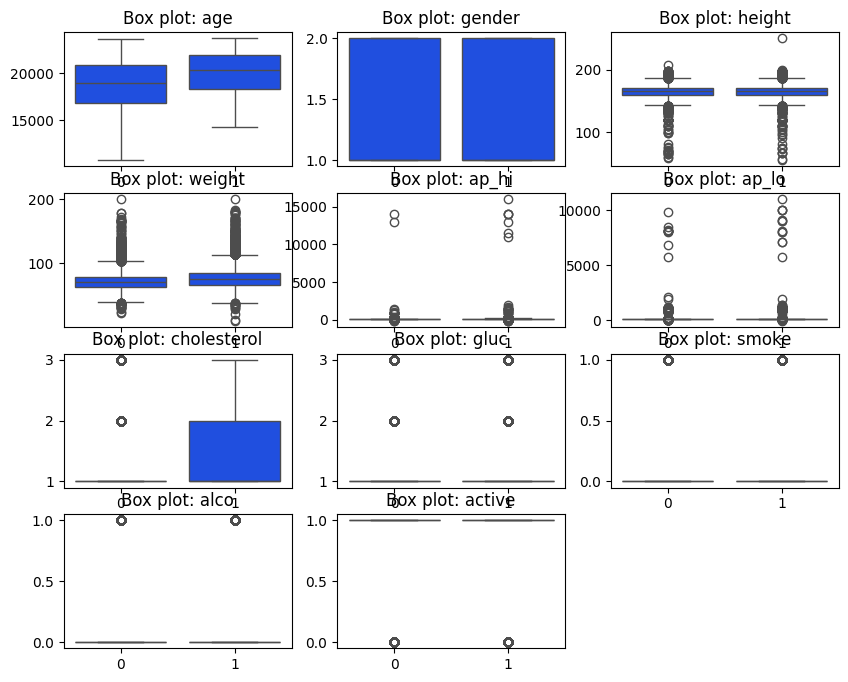

In [25]:
N_COLS = 3
N_ROWS = math.ceil(len(INPUT_FEATURES) / N_COLS)

plt.figure(figsize=(10, 8))

for i, feature in enumerate(INPUT_FEATURES):
    plt.subplot(N_ROWS, N_COLS, i+1)
    plt.title(f"Box plot: {feature}")
    sns.boxplot(df, x=TARGET, y=feature)
    plt.ylabel("")
    plt.xlabel('')
plt.show()

In [26]:
def plot_box(features, hue):
    ROW_WIDTH = 6
    temp = 0
    
    for num_feature in features:
        if temp == 0:
            plt.figure(figsize=(25 ,5))
        
        plt.subplot(1, ROW_WIDTH, temp + 1)
        plt.title(f"Box plot: {num_feature}")
        sns.boxplot(df, x = num_feature, hue=hue, palette='rocket')
        
        if temp == ROW_WIDTH - 1:
            plt.show()
        temp = (temp + 1) % ROW_WIDTH
    
    if temp != ROW_WIDTH - 1:
        plt.show()

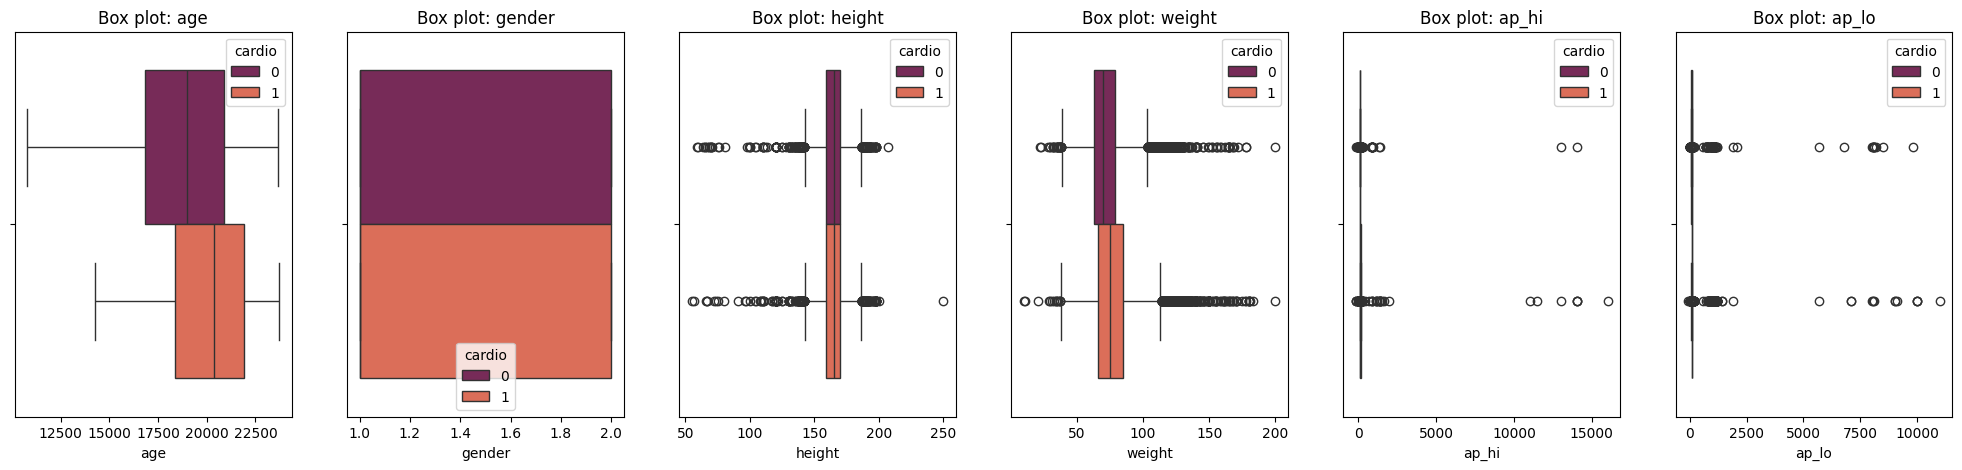

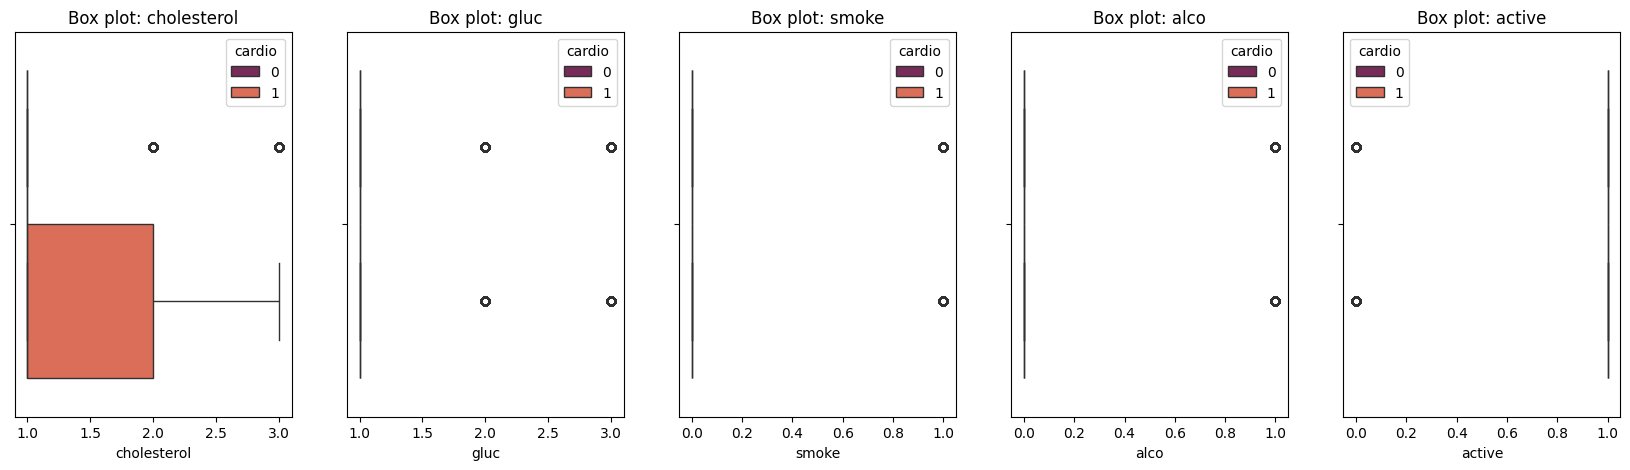

In [27]:
plot_box(INPUT_FEATURES, TARGET)

In [28]:
def IQR(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    
    IQR = Q3 - Q1
    
    min_v = Q1 - 1.5 * IQR
    max_v = Q3 + 1.5 * IQR
    
    return series.clip(lower=min_v, upper=max_v)

In [29]:
exclude = ['gluc','alco','smoke','colesterol','active']
for num_feature in [f for f in INPUT_FEATURES if f not in exclude]:
    for gender_category in df[TARGET].unique():
        mask = df[TARGET] == gender_category
        # print(mask)
        df.loc[mask, num_feature] = IQR(df.loc[mask, num_feature])
        

### Your Corrected Summary

1. Set up IQR boundaries at 25% and 75%
2. Squish anything outside those boundaries
3. Loop through numeric columns, skip binary ones
4. Loop through each group (both sick AND healthy) one at a time
5. Mask filters rows belonging to the current group being cleaned
6. Pass that filtered group's column into the IQR function

#### Point 4 — The second loop doesn't only look at "True/detected" cases. It loops through both classes — sick AND healthy people, one at a time.

- It cleans both groups — not just the positive detections.

#### Point 5 — The mask doesn't filter based on True/False disease detection. It filters based on which group we're currently cleaning.

##### It's not asking "who has the disease?"

##### It's asking "who belongs to the current group we're cleaning?"

mask = df[TARGET] == gender_category


### Question

why did we go through the `healthy` and `sick` one at a time, why no just go through it all at once since we are squishing the outliers of both of them?


### ANSWER

The Problem With Doing It All At Once

Healthy and sick people naturally have different normal ranges. For example, blood pressure:

- Healthy people: 100, 105, 110, 108, 102 → their normal range is LOW
- Sick people: 150, 160, 155, 165, 158 → their normal range is HIGH

If you mix them together and calculate IQR all at once:

- Combined: 100, 105, 110, 108, 102, 150, 160, 155, 165, 158
  ↑
  the boundary lands somewhere
  in the MIDDLE of both groups

The boundary ends up being unfair to both groups — it will squish healthy values that are perfectly normal for healthy people, and squish sick values that are perfectly normal for sick people.

By Separating Them

- Healthy group IQR → boundaries based on HEALTHY people's normal range
- Sick group IQR → boundaries based on SICK people's normal range

Each group gets judged by their own standard — so you only squish values that are genuinely weird within that group.


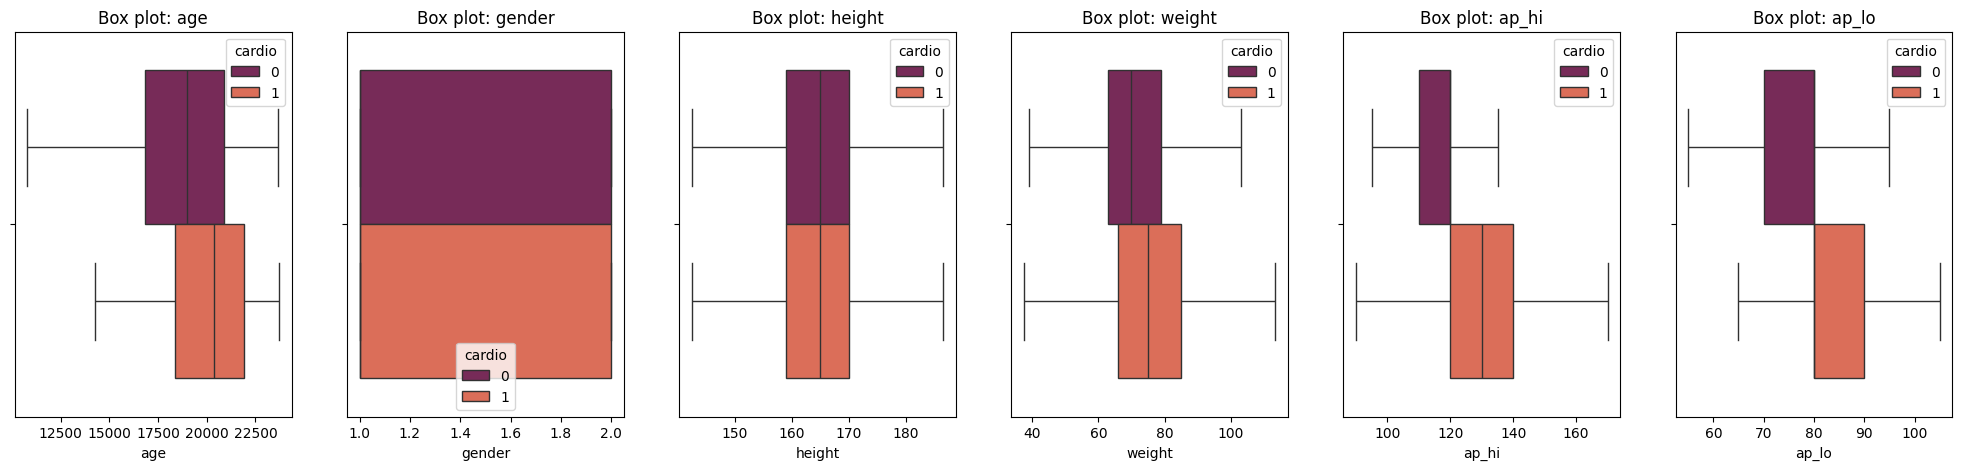

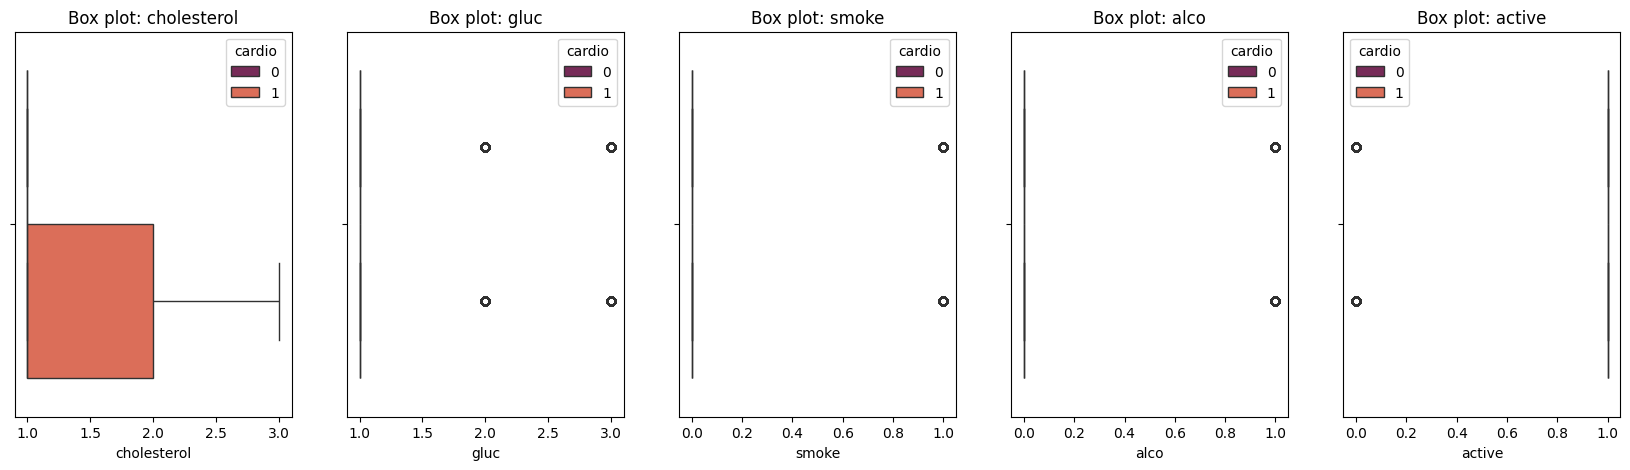

In [30]:
plot_box(INPUT_FEATURES, TARGET)

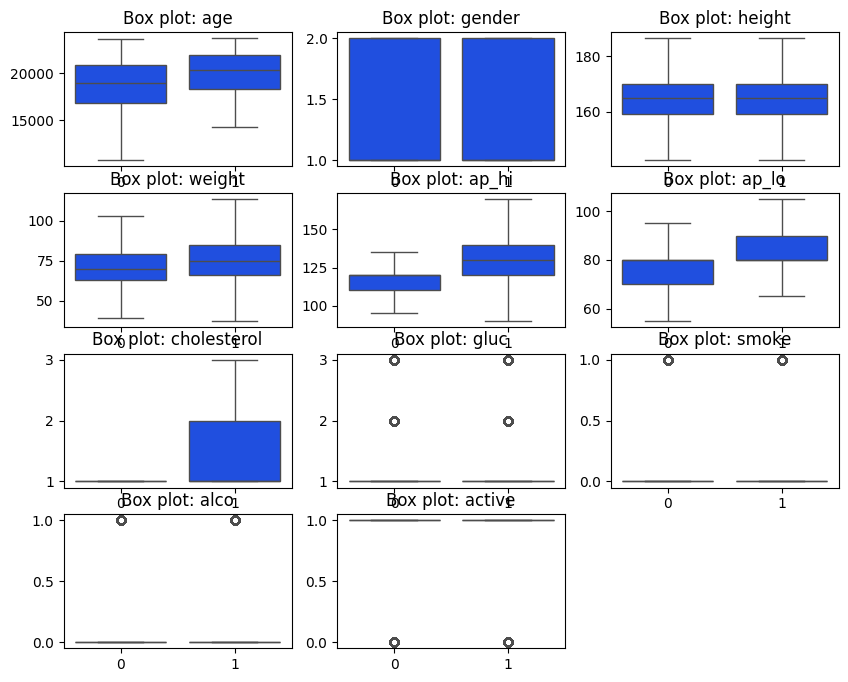

In [31]:
N_COLS = 3
N_ROWS = math.ceil(len(INPUT_FEATURES) / N_COLS)

plt.figure(figsize=(10, 8))

for i, feature in enumerate(INPUT_FEATURES):
    plt.subplot(N_ROWS, N_COLS, i+1)
    plt.title(f"Box plot: {feature}")
    sns.boxplot(df, x=TARGET, y=feature)
    plt.ylabel("")
    plt.xlabel('')
plt.show()

In [32]:
INPUT_FEATURES

['age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active']

In [33]:
df.head(5)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168.0,62.0,110,80,1,1,0,0,1,0
1,20228,1,156.0,85.0,140,90,3,1,0,0,1,1
2,18857,1,165.0,64.0,130,70,3,1,0,0,0,1
3,17623,2,169.0,82.0,150,100,1,1,0,0,1,1
4,17474,1,156.0,56.0,100,60,1,1,0,0,0,0


In [34]:
df['age_years'] = (df['age'] / 365).round().astype(int)

In [35]:
df['height'] = df['height'] / 100

In [36]:
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

In [37]:
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

In [38]:
df['health_index'] = (df['active'] * 1) - (df['smoke'] * 0.5) - (df['alco'] * 0.5)

In [39]:
df['cholesterol_gluc_interaction'] = df['cholesterol'] * df['gluc']

In [40]:
new_features = [
    'age_years',
    'bmi',
    'pulse_pressure',
    'health_index',
    'cholesterol_gluc_interaction'
]
INPUT_FEATURES = INPUT_FEATURES + [f for f in new_features if f not in INPUT_FEATURES]

INPUT_FEATURES

['age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'age_years',
 'bmi',
 'pulse_pressure',
 'health_index',
 'cholesterol_gluc_interaction']

In [41]:
df = drop_unwanted_features(df, 'age')
df = drop_unwanted_features(df, 'height')

Dropping features: age
Dropping features: height


In [42]:
df.head(5)

,gender,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,health_index,cholesterol_gluc_interaction
0,2,62.0,110,80,1,1,0,0,1,0,50,219671.201814,30,1.0,1
1,1,85.0,140,90,3,1,0,0,1,1,55,349276.791584,50,1.0,3
2,1,64.0,130,70,3,1,0,0,0,1,52,235078.053260,60,0.0,3
3,2,82.0,150,100,1,1,0,0,1,1,48,287104.793250,50,1.0,1
4,1,56.0,100,60,1,1,0,0,0,0,48,230111.768573,40,0.0,1


In [43]:
df.columns

Index(['gender', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke',
       'alco', 'active', 'cardio', 'age_years', 'bmi', 'pulse_pressure',
       'health_index', 'cholesterol_gluc_interaction'],
      dtype='object')

In [44]:
INPUT_FEATURES=['gender', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke',
       'alco', 'active', 'age_years', 'bmi', 'pulse_pressure',
       'health_index', 'cholesterol_gluc_interaction']

In [45]:
INPUT_FEATURES

['gender',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'age_years',
 'bmi',
 'pulse_pressure',
 'health_index',
 'cholesterol_gluc_interaction']

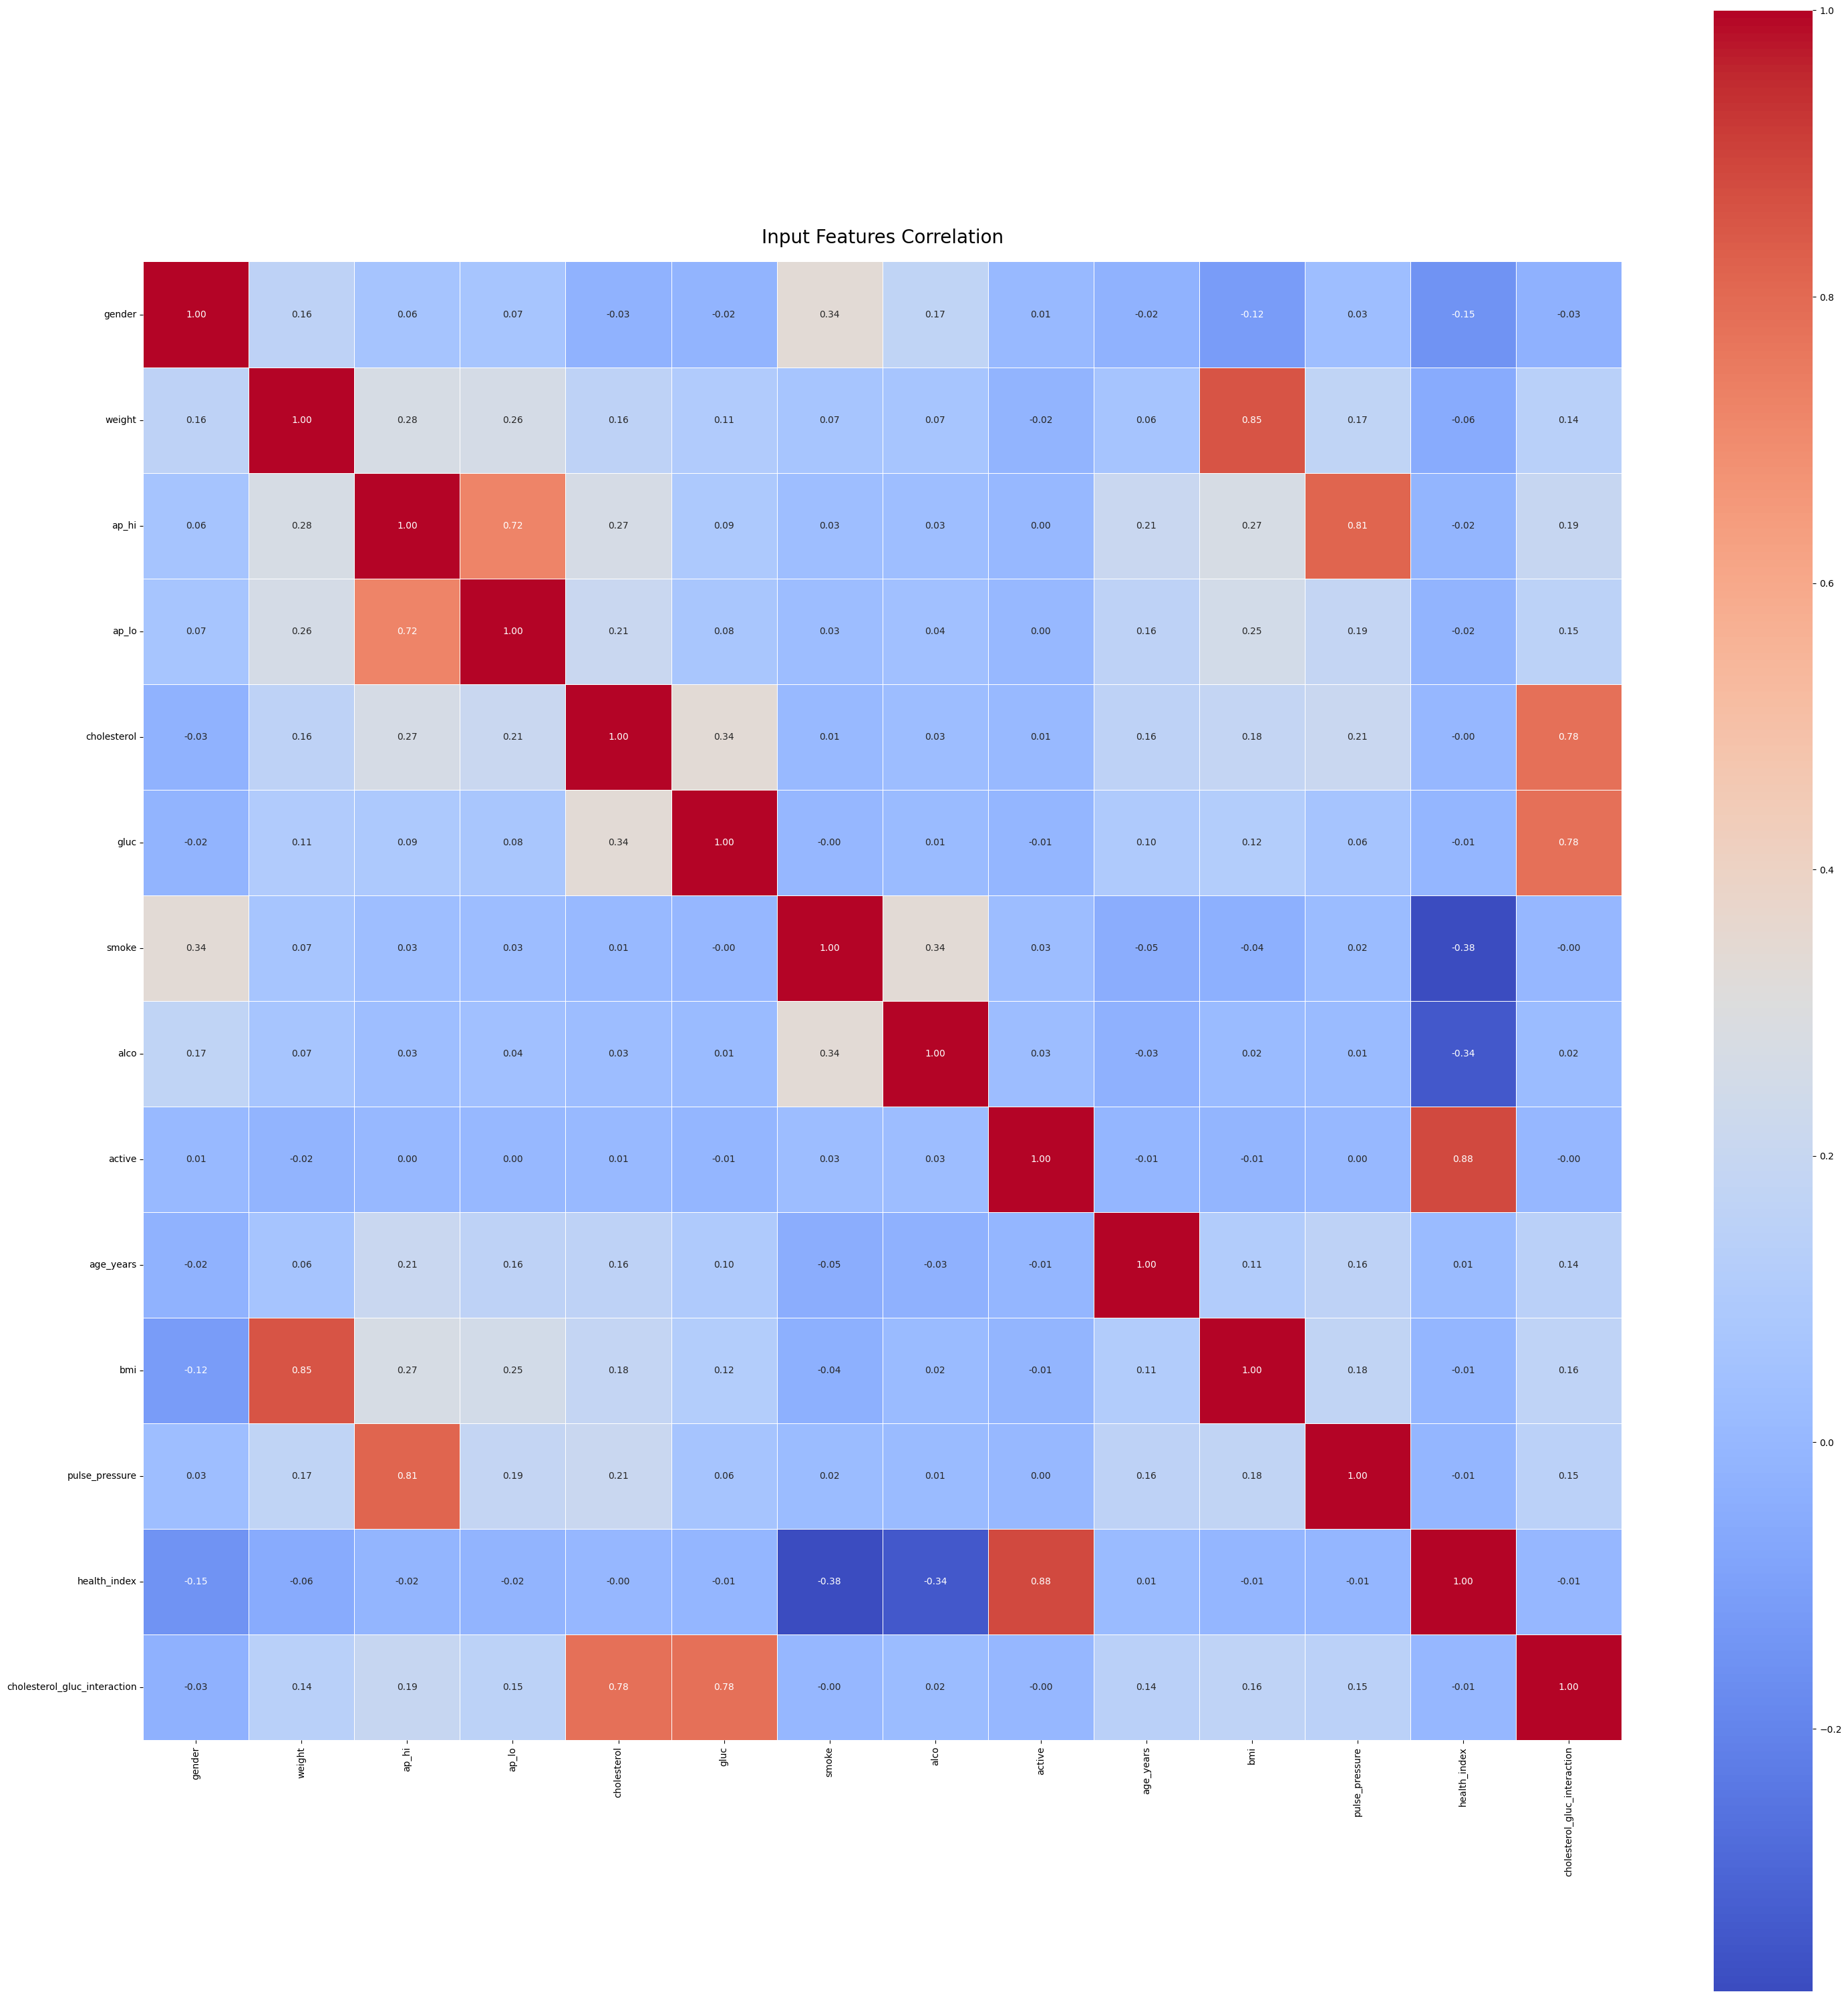

Saved as correlation_matrix.png ✅


In [46]:
plt.figure(figsize=(30, 30))

plt.title("Input Features Correlation", fontsize=20, pad=20)

sns.heatmap(
    df[INPUT_FEATURES].corr(),
    annot=True,          # show the numbers inside each cell
    cmap='coolwarm',     # red/blue color scheme
    fmt='.2f',           # round numbers to 2 decimal places
    linewidths=0.5,      # add lines between cells
    square=True,         # make each cell a perfect square
    )

plt.tight_layout()       # make sure nothing gets cut off

plt.savefig('correlation_matrix.png', 
            dpi=150,                    # image quality
            bbox_inches='tight'         # don't cut off the edges
            )

plt.show()

print("Saved as correlation_matrix.png ✅")

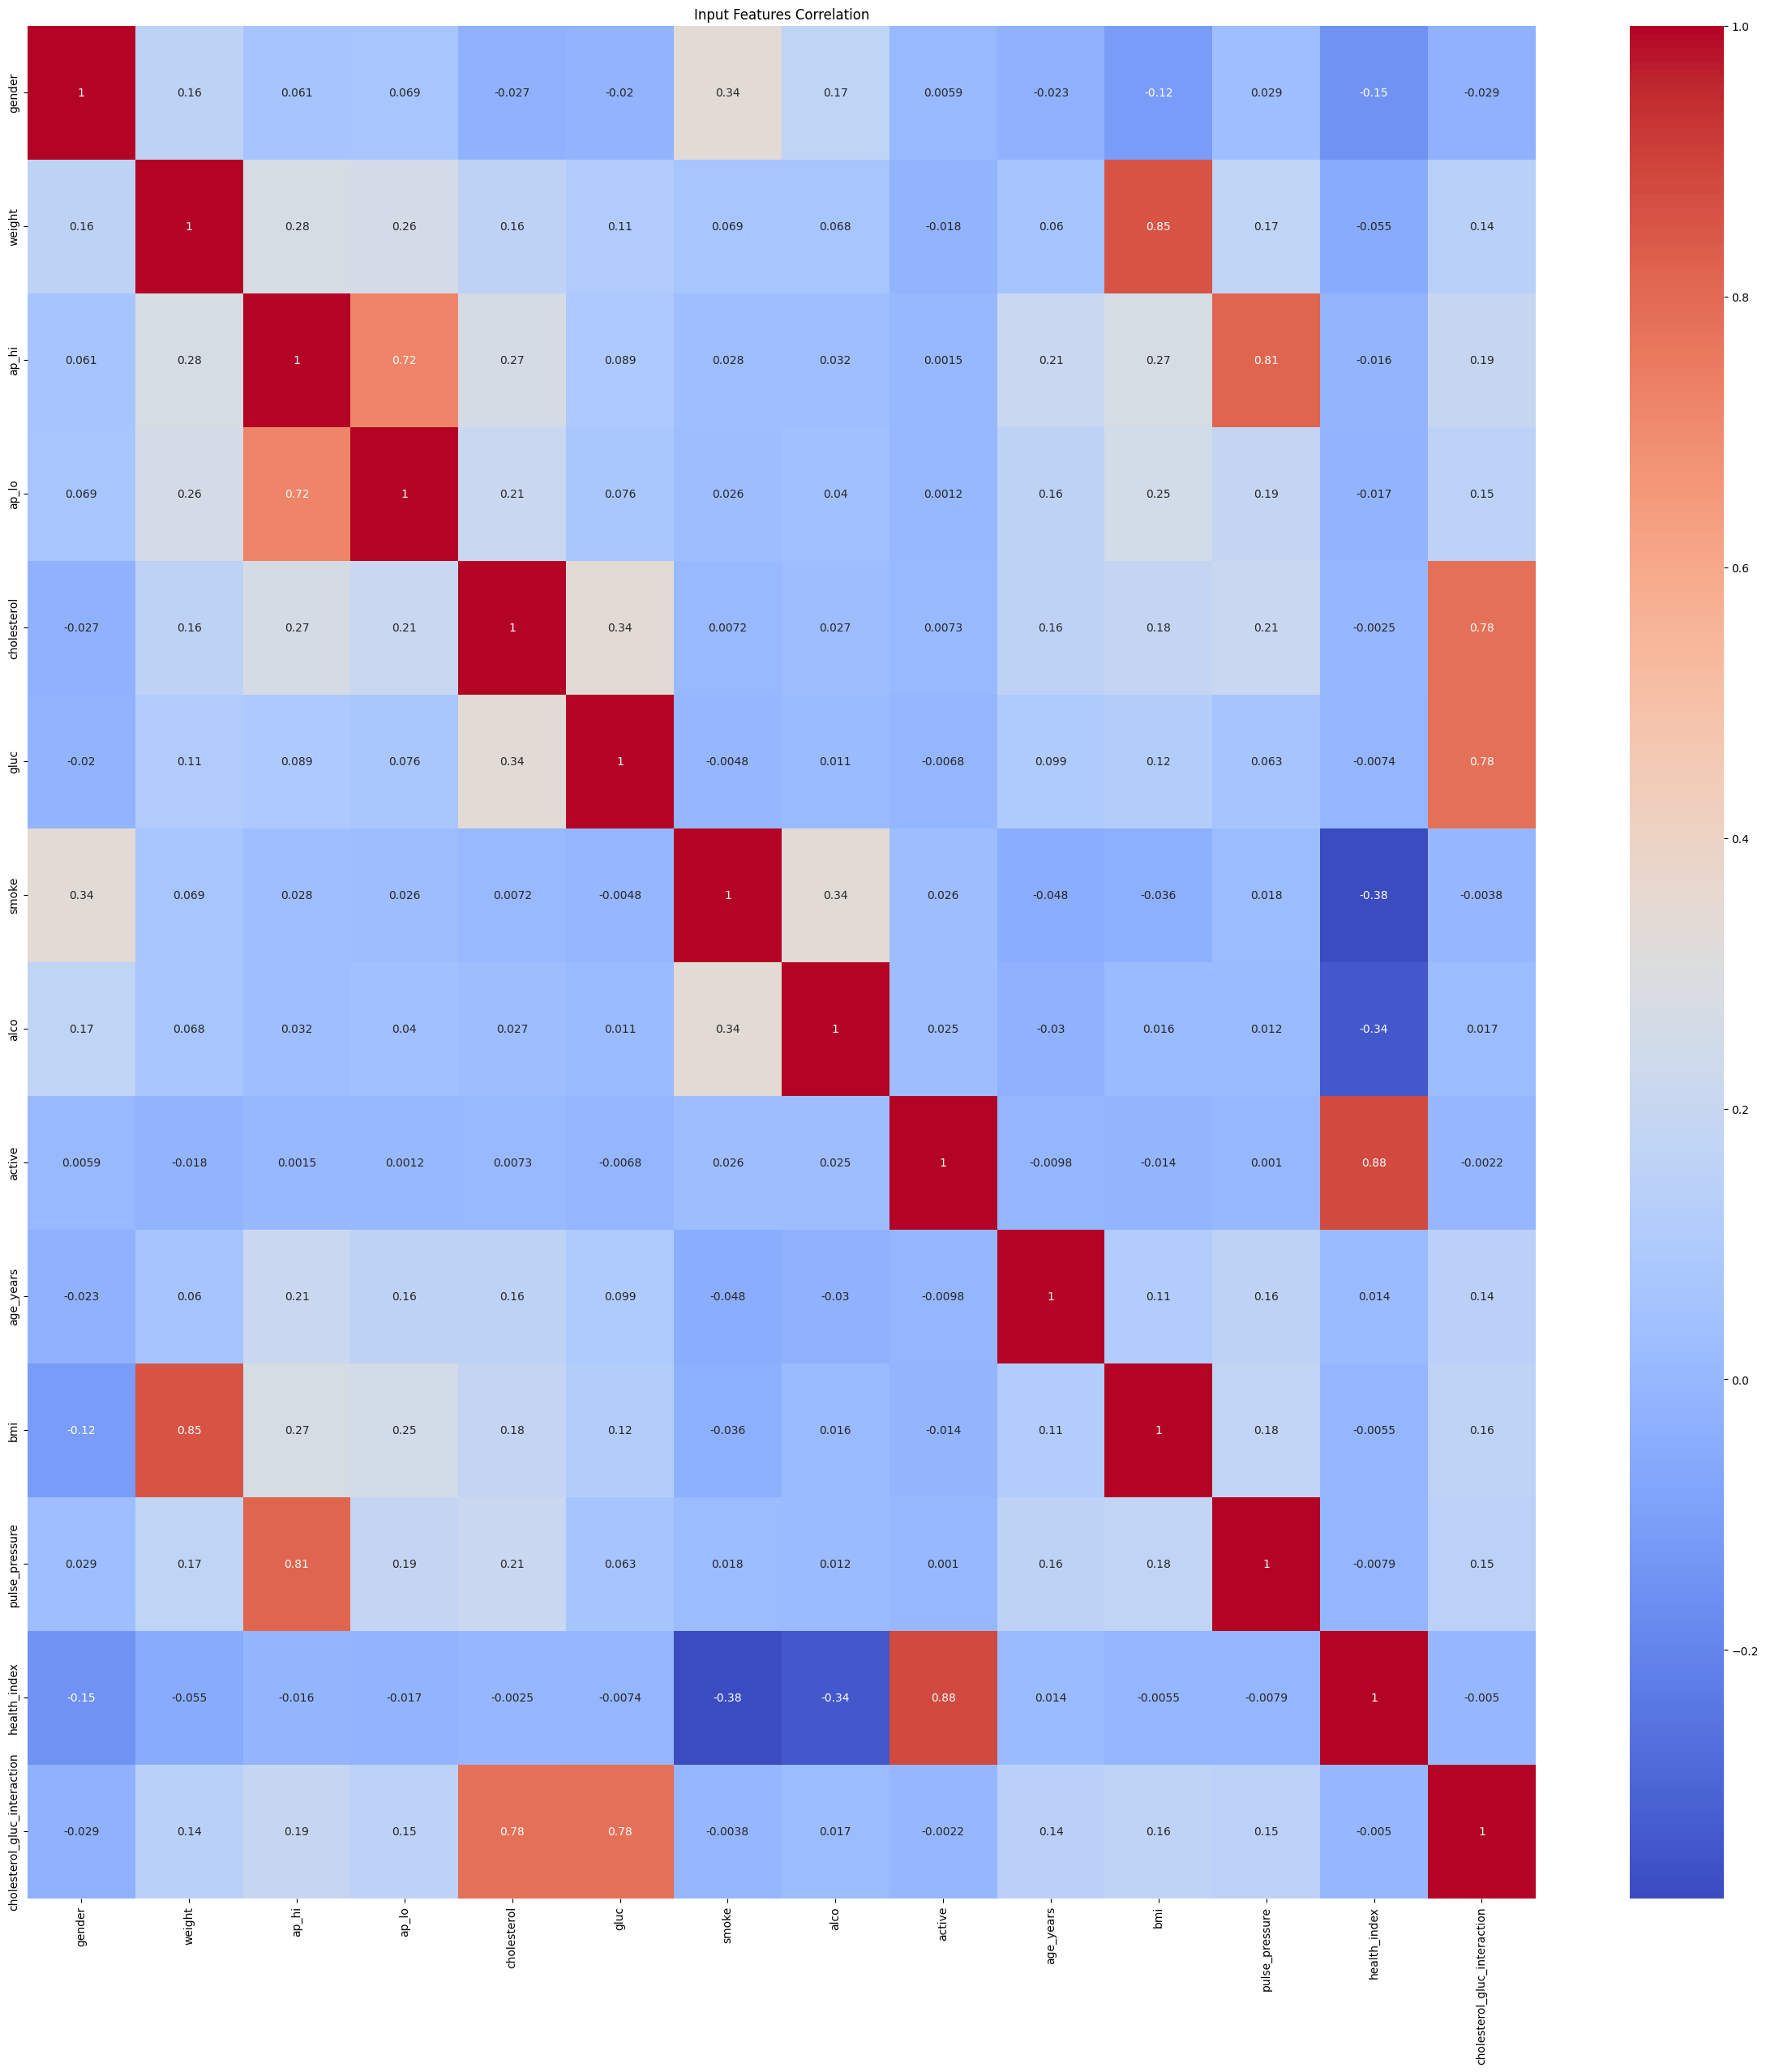

In [47]:
plt.figure(figsize=(30, 30))

plt.title("Input Features Correlation")

sns.heatmap(
    df[INPUT_FEATURES].corr(),
    annot=True,
    cmap='coolwarm',
    )

plt.show()

F1 test (ANOVA)

F-value: Measures how much the means between groups differ relative to the variance within the groups. Higher = more likely the feature is important.

p-value: Probability that the observed difference is due to chance.

p < 0.05 → Statistically significant

p ≥ 0.05 → Not significant


In [48]:
f_values, p_values = f_classif(df[INPUT_FEATURES], df[TARGET])

f_values
for i in range(len(INPUT_FEATURES)):
    print(f"{INPUT_FEATURES[i]:15s}: f-value = {f_values[i]:6.3f}, p-value = {p_values[i]:3.3f}")

gender         : f-value =  4.604, p-value = 0.032
weight         : f-value = 2702.000, p-value = 0.000
ap_hi          : f-value = 21922.892, p-value = 0.000
ap_lo          : f-value = 11575.413, p-value = 0.000
cholesterol    : f-value = 15554.452, p-value = 0.000
gluc           : f-value = 562.773, p-value = 0.000
smoke          : f-value = 16.791, p-value = 0.000
alco           : f-value =  3.761, p-value = 0.052
active         : f-value = 89.091, p-value = 0.000
age_years      : f-value = 4193.662, p-value = 0.000
bmi            : f-value = 3015.623, p-value = 0.000
pulse_pressure : f-value = 11607.067, p-value = 0.000
health_index   : f-value = 44.285, p-value = 0.000
cholesterol_gluc_interaction: f-value = 6925.072, p-value = 0.000


What The Code Above Does.
It's a statistical test that measures how useful each feature is at predicting your target (disease or no disease)

`f_classif()` - The Main Function

f_values, p_values = f_classif(df[INPUT_FEATURES], df[TARGET])

```

This function asks one question for each column:

> **"Does this column's values actually differ between sick and healthy people?"**

It returns two things:
- **f_values** — how different the groups are
- **p_values** — how trustworthy that difference is

---

### The F-Value

Think of it as a **usefulness score** for each feature:
```

f-value = 0.1 → barely any difference between sick/healthy 😴
f-value = 50 → big difference between sick/healthy 🎯
f-value = 200 → huge difference — very useful feature! 🔥

```

Higher = better = more useful for predicting disease.

---

### The P-Value

This answers: **"Could this difference just be random luck?"**
```

p-value = 0.001 → only 0.1% chance it's luck → TRUSTWORTHY ✅
p-value = 0.5 → 50% chance it's luck → NOT trustworthy ❌

```

The golden rule:
```

p-value < 0.05 ✅ = the feature is statistically significant
p-value > 0.05 ❌ = could just be random noise, ignore this feature


## Scaling


In [49]:
df.describe()

,gender,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,health_index,cholesterol_gluc_interaction
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,1.349571,73.963974,126.230657,81.527071,1.258543,1.226457,0.088129,0.053771,0.803729,0.499700,53.338686,274023.397198,44.703586,0.732779,1.661729
std,0.476838,13.564876,15.593516,9.240543,0.606716,0.572270,0.283484,0.225568,0.397179,0.500003,6.765294,49827.573943,10.962455,0.442992,1.621911
min,1.000000,37.500000,90.000000,55.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000,118356.268148,-15.000000,-1.000000,1.000000
25%,1.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000,238751.147842,40.000000,0.500000,1.000000
50%,1.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000,263778.980980,40.000000,1.000000,1.000000
75%,2.000000,82.000000,135.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000,301204.819277,50.000000,1.000000,2.000000
max,2.000000,113.500000,170.000000,105.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000,558941.212681,105.000000,1.000000,9.000000


In [50]:
df.head()

,gender,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,health_index,cholesterol_gluc_interaction
0,2,62.0,110,80,1,1,0,0,1,0,50,219671.201814,30,1.0,1
1,1,85.0,140,90,3,1,0,0,1,1,55,349276.791584,50,1.0,3
2,1,64.0,130,70,3,1,0,0,0,1,52,235078.053260,60,0.0,3
3,2,82.0,150,100,1,1,0,0,1,1,48,287104.793250,50,1.0,1
4,1,56.0,100,60,1,1,0,0,0,0,48,230111.768573,40,0.0,1


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(TARGET, axis=1),
    df.loc[:, TARGET],
    test_size=0.25,
    random_state=1234,
    stratify=df.loc[:, TARGET],
)

In [52]:
print(f"{X_train.shape= }")
print(f"{y_train.shape= }")
print(f"{X_test.shape= }")
print(f"{y_test.shape= }")

X_train.shape= (52500, 14)
y_train.shape= (52500,)
X_test.shape= (17500, 14)
y_test.shape= (17500,)


In [53]:
y_train.value_counts()

cardio
0    26266
1    26234
Name: count, dtype: int64

In [54]:
y_test.value_counts()

cardio
0    8755
1    8745
Name: count, dtype: int64

In [55]:
list(X_train.columns)

['gender',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'age_years',
 'bmi',
 'pulse_pressure',
 'health_index',
 'cholesterol_gluc_interaction']

### Model Definition & Training


In [56]:
CACHE_MODELS_DIR_NAME = 'models_cache'
os.makedirs(CACHE_MODELS_DIR_NAME, exist_ok=True)

In [57]:
import os
import pickle
import re

class CustomModel:
    def __init__(self, name, model, extra_train_param=None):
        self.name = str(name)
        self.model = model
        self.extra_train_param = extra_train_param
        
        self.y_train_hat = None
        self.y_test_hat = None
        self.feature_names = None
        
        self.load()
    
    def fit(self, x_train, y_train):
        if not getattr(self, "trained", False):
            if self.extra_train_param is None:
                self.model.fit(x_train, y_train)
            else: 
                self.model.fit(x_train, y_train, **self.extra_train_param)
            
            self.feature_names = list(x_train.columns)
            self.trained = True
            self.save()
    
    def _align_features(self, X):
        if self.feature_names is not None:
            missing_cols = set(self.feature_names) - set(X.columns)
            extra_cols = set(X.columns) - set(self.feature_names)
            
            if missing_cols:
                raise ValueError(f"Missing columns in input: {missing_cols}")
            if extra_cols:
                X = X[self.feature_names]
            else:
                X = X[self.feature_names]
        return X
    def predict_on_train(self, x_train):
        if self.y_train_hat is None:
            x_train = self._align_features(x_train)
            self.y_train_hat = self.model.predict(x_train)
            
    def predict_on_test(self, x_test):
        if self.y_test_hat is None:
            x_test = self._align_features(x_test)
            self.y_test_hat = self.model.predict(x_test)
    
    def save(self):
        file_name = re.sub(r'\W+', '_', str(self.name).lower())
        file_path = CACHE_MODELS_DIR_NAME + '/' + file_name + '.pickle'
        with open(file_path, 'wb') as f:
            pickle.dump(
                {
                    "model": self.model,
                    "trained": self.trained,
                    "feature_names": self.feature_names
                },
                f
            )
    
    def load(self):
        file_name = re.sub(r'\W+', '_', str(self.name).lower())
        file_path = CACHE_MODELS_DIR_NAME + '/' + file_name + '.pickle'
        if os.path.exists(file_path):
            with open(file_path, 'rb') as f:
                data = pickle.load(f)
                self.model = data["model"]
                self.trained = data["trained"]
                self.feature_names = data.get("feature_names", None)
        else:
            self.trained = False

In [58]:
import os

# delete the corrupted files
os.remove(CACHE_MODELS_DIR_NAME + '/logistic_regression.pickle')

In [59]:
models_list = []

models_list.append(CustomModel("Logistic Regression", LogisticRegression()))

# models_list.append(CustomModel("SVC rbf sigmoid", SVC( ))) #بيطول بغباء

models_list.append(CustomModel("Decision Tree max-depth=7", DecisionTreeClassifier(max_depth=7 )))
models_list.append(CustomModel("Decision Tree max-depth=10", DecisionTreeClassifier(max_depth=10,min_samples_split=7,min_samples_leaf=3,criterion='gini' )))

models_list.append(CustomModel("Random Forest, trees=3", RandomForestClassifier(n_estimators=3 )))
models_list.append(CustomModel("Random Forest, trees=5", RandomForestClassifier(n_estimators=5 )))


# models_list.append(CustomModel("Ada Boost estimator=5 max_depth=2", AdaBoostClassifier(n_estimators=5, estimator=RandomForestClassifier(max_depth=2))))

models_list.append(CustomModel("Gradient Boosting estimator=3", GradientBoostingClassifier(n_estimators=3)))

In [60]:
for i, model in enumerate(models_list):
    print(f'{i+1:3d}/{len(models_list)}. Train {model.name}')
    model.fit(X_train, y_train)

  1/6. Train Logistic Regression
  2/6. Train Decision Tree max-depth=7
  3/6. Train Decision Tree max-depth=10
  4/6. Train Random Forest, trees=3
  5/6. Train Random Forest, trees=5
  6/6. Train Gradient Boosting estimator=3


In [61]:
for i, model in enumerate(models_list):
    print(f'{i+1:3d}/{len(models_list)}. Predict {model.name} on train data')
    model.predict_on_train(X_train)

  1/6. Predict Logistic Regression on train data


  2/6. Predict Decision Tree max-depth=7 on train data
  3/6. Predict Decision Tree max-depth=10 on train data
  4/6. Predict Random Forest, trees=3 on train data
  5/6. Predict Random Forest, trees=5 on train data
  6/6. Predict Gradient Boosting estimator=3 on train data


In [62]:
for i, model in enumerate(models_list):
    print(f'{i+1:3d}/{len(models_list)}. Predict {model.name} on test data')
    model.predict_on_test(X_test)

  1/6. Predict Logistic Regression on test data
  2/6. Predict Decision Tree max-depth=7 on test data
  3/6. Predict Decision Tree max-depth=10 on test data
  4/6. Predict Random Forest, trees=3 on test data
  5/6. Predict Random Forest, trees=5 on test data
  6/6. Predict Gradient Boosting estimator=3 on test data


In [63]:
evaluation_dataset = []

for i, model in enumerate(models_list):
    print(f'{i+1:02d}/{len(models_list)}. Evaluate {model.name}')
    
    accuracy_score_train = accuracy_score(y_train, model.y_train_hat)
    accuracy_score_test = accuracy_score(y_test, model.y_test_hat)
    
    recall_score_train = recall_score(y_train, model.y_train_hat)
    recall_score_test = recall_score(y_test, model.y_test_hat)
    
    precision_score_train = precision_score(y_train, model.y_train_hat)
    precision_score_test = precision_score(y_test, model.y_test_hat)
    
    f1_score_train = f1_score(y_train, model.y_train_hat)
    f1_score_test = f1_score(y_test, model.y_test_hat)
    
    roc_auc_score_train = roc_auc_score(y_train, model.y_train_hat)
    roc_auc_score_test = roc_auc_score(y_test, model.y_test_hat)
    
    evaluation_dataset.append({
        "model": model.name, 'accuracy_score': accuracy_score_train,
        'recall_score': recall_score_train, 
        'f1_score': f1_score_train,
        'roc_auc_score': roc_auc_score_train, 
        'precision_score': precision_score_train,
        'data': 'train'
    })
    
    evaluation_dataset.append({
        "model": model.name, 'accuracy_score': accuracy_score_test,
        'recall_score': recall_score_test, 'f1_score':f1_score_test,
        'roc_auc_score':roc_auc_score_test, 'precision_score':precision_score_test,
        'data':'test'}
    )
    
    

evaluation_dataset = pd.DataFrame(evaluation_dataset)
      
    

01/6. Evaluate Logistic Regression
02/6. Evaluate Decision Tree max-depth=7
03/6. Evaluate Decision Tree max-depth=10
04/6. Evaluate Random Forest, trees=3
05/6. Evaluate Random Forest, trees=5
06/6. Evaluate Gradient Boosting estimator=3


In [64]:
evaluation_dataset.sort_values('f1_score', ascending=False)

,model,accuracy_score,recall_score,f1_score,roc_auc_score,precision_score,data
8,"Random Forest, trees=5",0.937390,0.941641,0.937620,0.937393,0.933633,train
6,"Random Forest, trees=3",0.921276,0.924830,0.921511,0.921278,0.918215,train
5,Decision Tree max-depth=10,0.800971,0.657633,0.767568,0.800890,0.921635,test
4,Decision Tree max-depth=10,0.799924,0.657467,0.766578,0.799837,0.919109,train
3,Decision Tree max-depth=7,0.795600,0.640252,0.757902,0.795511,0.928524,test
9,"Random Forest, trees=5",0.762914,0.730818,0.754947,0.762896,0.780723,test
2,Decision Tree max-depth=7,0.791638,0.635740,0.753042,0.791543,0.923426,train
7,"Random Forest, trees=3",0.757314,0.728416,0.749985,0.757298,0.772871,test
11,Gradient Boosting estimator=3,0.785029,0.569811,0.725962,0.784906,1.000000,test
10,Gradient Boosting estimator=3,0.784362,0.568461,0.724865,0.784230,1.000000,train


In [65]:
evaluation_dataset[evaluation_dataset['data']=='test'].sort_values('f1_score',ascending=False)

,model,accuracy_score,recall_score,f1_score,roc_auc_score,precision_score,data
5,Decision Tree max-depth=10,0.800971,0.657633,0.767568,0.800890,0.921635,test
3,Decision Tree max-depth=7,0.795600,0.640252,0.757902,0.795511,0.928524,test
9,"Random Forest, trees=5",0.762914,0.730818,0.754947,0.762896,0.780723,test
7,"Random Forest, trees=3",0.757314,0.728416,0.749985,0.757298,0.772871,test
11,Gradient Boosting estimator=3,0.785029,0.569811,0.725962,0.784906,1.000000,test
1,Logistic Regression,0.499714,1.000000,0.666413,0.500000,0.499714,test


In [66]:
print("Best Model in F1 Score test")
evaluation_dataset[evaluation_dataset['data']=='test'].sort_values('f1_score',ascending=False).iloc[0,:]

Best Model in F1 Score test


model              Decision Tree max-depth=10
accuracy_score                       0.800971
recall_score                         0.657633
f1_score                             0.767568
roc_auc_score                         0.80089
precision_score                      0.921635
data                                     test
Name: 5, dtype: object

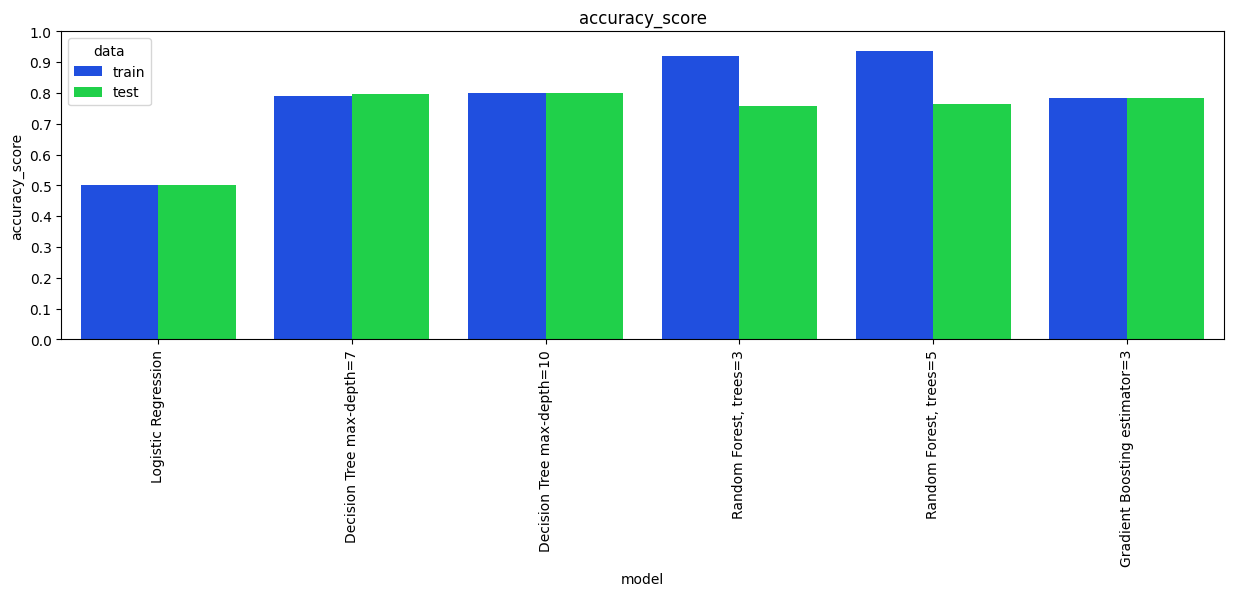

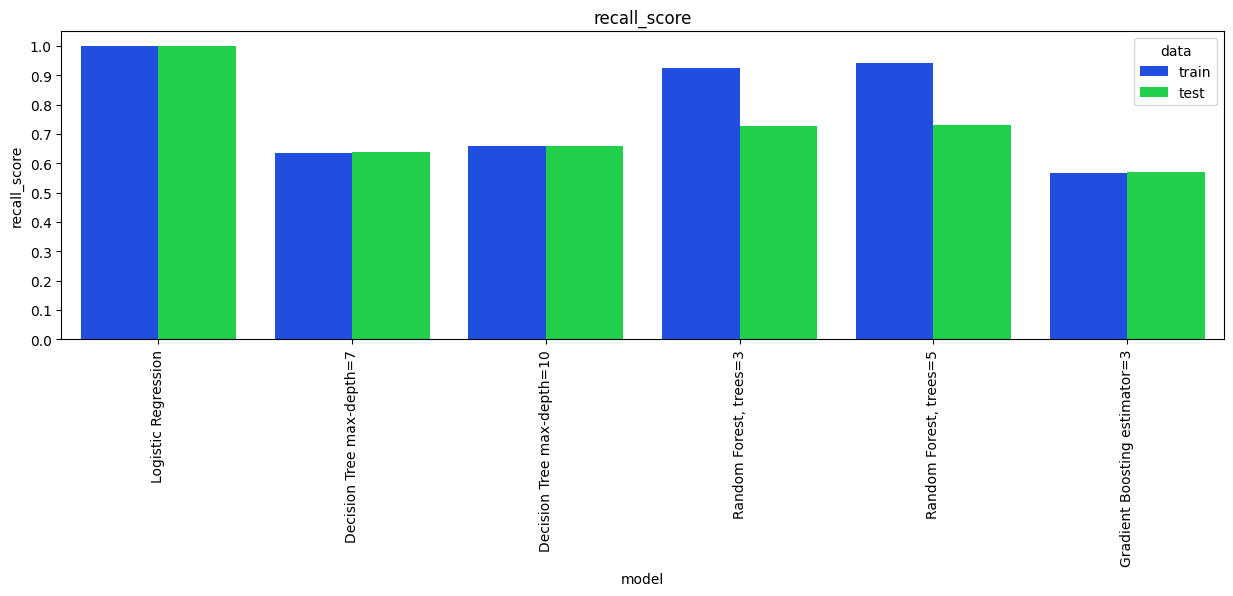

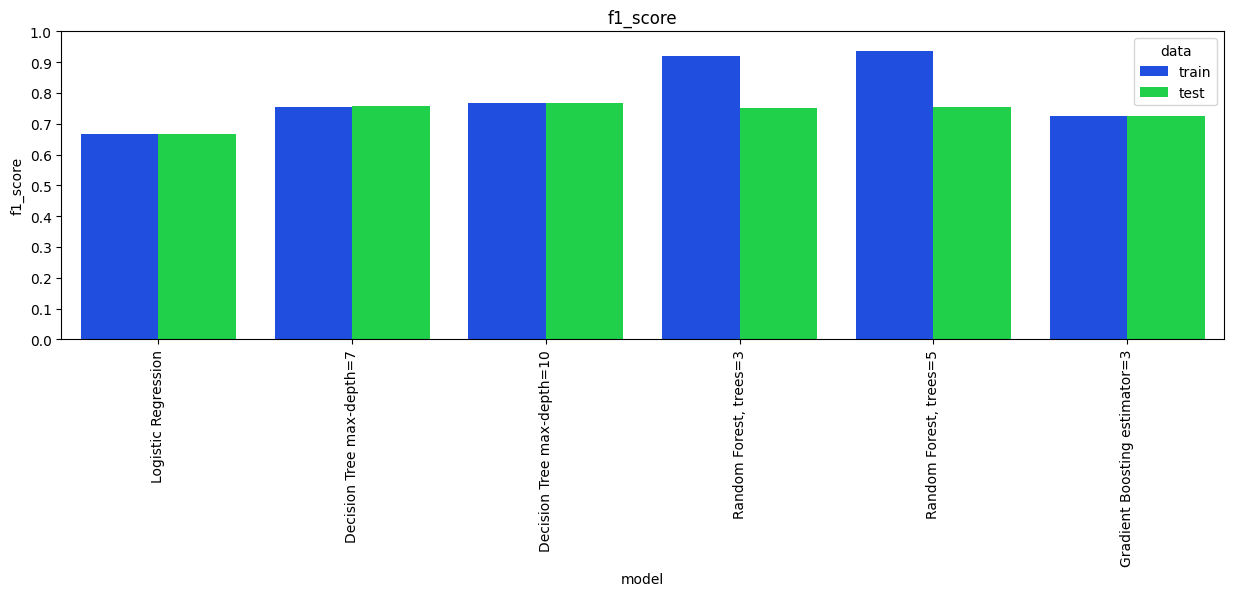

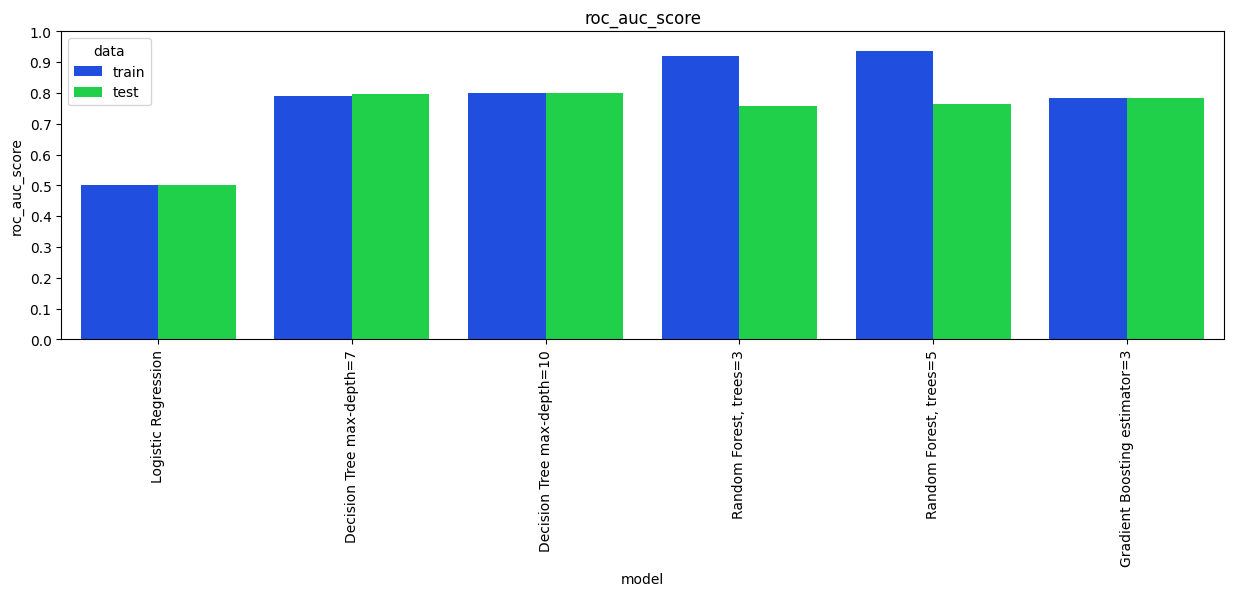

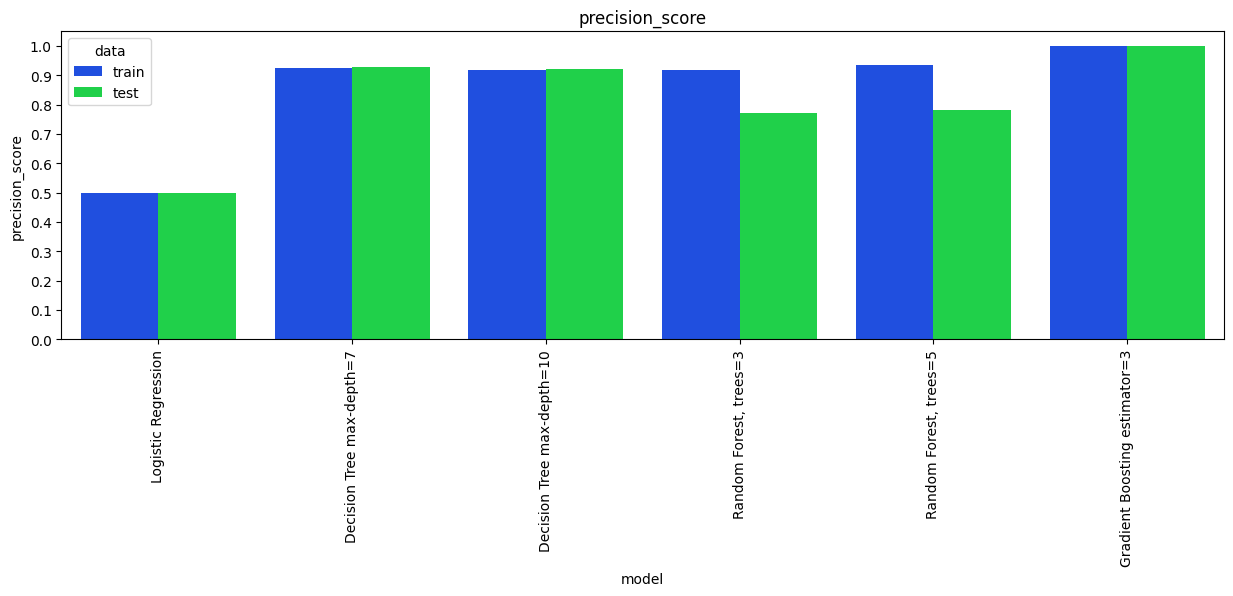

In [67]:
for metric in evaluation_dataset.columns:
    if metric in ['model', 'data']:
        continue

    plt.figure(figsize=(15,4))
    plt.title(f"{metric}")
    sns.barplot(evaluation_dataset, x='model',y=metric, hue='data')
    plt.xticks(rotation = 90)
    plt.yticks(np.linspace(0,1,11))
    plt.show()

In [68]:
evaluation_dataset.to_csv("eval_dataset.csv")

In [69]:
CAHCE_Y_VS_Y_HAT_DIR_NAME = 'models_predictions'
os.makedirs(CAHCE_Y_VS_Y_HAT_DIR_NAME, exist_ok=True)

In [70]:
for model in models_list:
    pad_width = len(y_train) - len(y_test)

    pd.DataFrame(
        {
            'actual Y train' : y_train,
            'predict Y train' : model.y_train_hat,
            'Train Diff':  y_train - model.y_train_hat,
            'actual Y test' : np.pad(y_test, (0, pad_width), mode='constant', constant_values=-1),
            'predict Y test' : np.pad(model.y_test_hat, (0, pad_width), mode='constant', constant_values=-1),
            'Test Diff':  np.pad(y_test - model.y_test_hat, (0, pad_width), mode='constant'),
#
        }
    ).to_csv(f"{CAHCE_Y_VS_Y_HAT_DIR_NAME}/{model.name}.csv")

In [71]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Create Decision Tree with max depth 10
clf = DecisionTreeClassifier(max_depth=10, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}")

Accuracy: 0.83


In [72]:
X_train

,gender,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,bmi,pulse_pressure,health_index,cholesterol_gluc_interaction
30319,1,75.0,110,80,1,1,0,0,0,41,247720.967103,30,0.0,1
59355,2,94.0,120,80,1,1,0,0,1,50,337050.449998,40,1.0,1
21321,1,85.0,135,90,1,1,0,0,1,49,319921.713275,45,1.0,1
53768,1,110.0,170,100,1,1,0,0,0,54,429687.500000,70,0.0,1
33684,1,53.0,110,80,1,2,0,0,1,50,223477.820880,30,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13266,2,98.0,130,80,1,1,1,0,0,52,305858.119285,50,-0.5,1
51202,2,76.0,120,80,1,1,0,0,1,56,248163.265306,40,1.0,1
24640,1,70.0,110,70,1,1,0,0,0,47,242214.532872,40,0.0,1
67654,1,59.5,95,70,1,1,0,0,1,50,218549.127640,25,1.0,1
